# Comprehensive Guide to Model Evaluation & Statistical Analysis
## A Beginner's Tutorial for Comparing Machine Learning Models

---

### 📚 What You'll Learn:
1. **Performance Metrics**: Understanding Accuracy, Precision, Recall, and AUC-ROC
2. **Why Multiple Metrics Matter**: The complete picture of model performance
3. **ROC Curves**: Visualizing and interpreting model performance
4. **Statistical Tests**: Validating that model differences are real, not random
5. **Cross-Cancer Comparisons**: Evaluating models across different datasets

---

### 🎯 Learning Objectives:
- Compare multiple ML models rigorously
- Understand which metric to use when
- Validate that model differences are statistically significant
- Make informed decisions about model selection

## 📦 Setup: Installing Required Libraries

First, let's install and import all the libraries we'll need.

In [1]:
# Install required packages (run once)
# !pip install numpy pandas scikit-learn matplotlib seaborn scipy

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    classification_report
)

# Set random seed for reproducibility
np.random.seed(42)

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

## 🧬 Part 1: Creating Synthetic Cancer Datasets

### What are we doing?
We're creating **synthetic (fake but realistic) datasets** that simulate cancer detection scenarios across different cancer types. This helps us understand model evaluation without needing real patient data.

### Why multiple cancer types?
Different cancers have different characteristics:
- **Breast Cancer**: Might have clear biomarkers (easier to detect)
- **Lung Cancer**: More complex patterns
- **Colorectal Cancer**: Different feature distributions

A good model should work well across all types!

In [3]:
def create_cancer_dataset(n_samples=1000, n_features=20, difficulty='medium', random_state=42):
    """
    Creates a synthetic cancer dataset.
    
    Parameters:
    - n_samples: Number of patients in the dataset
    - n_features: Number of biomarkers/features measured
    - difficulty: How hard it is to classify ('easy', 'medium', 'hard')
    - random_state: For reproducibility
    
    Returns:
    - X: Features (biomarkers, genetic data, etc.)
    - y: Labels (0 = No cancer, 1 = Cancer)
    """
    difficulty_params = {
        'easy': {'n_informative': 15, 'n_redundant': 3, 'n_clusters_per_class': 1, 'flip_y': 0.05},
        'medium': {'n_informative': 10, 'n_redundant': 5, 'n_clusters_per_class': 2, 'flip_y': 0.1},
        'hard': {'n_informative': 5, 'n_redundant': 8, 'n_clusters_per_class': 3, 'flip_y': 0.2}
    }
    
    params = difficulty_params[difficulty]
    
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=params['n_informative'],
        n_redundant=params['n_redundant'],
        n_clusters_per_class=params['n_clusters_per_class'],
        flip_y=params['flip_y'],
        random_state=random_state
    )
    
    return X, y

# Create three different cancer datasets
print("🧬 Creating cancer datasets...\n")

# Breast Cancer (relatively easier to detect)
X_breast, y_breast = create_cancer_dataset(n_samples=1000, difficulty='easy', random_state=42)
print(f"✓ Breast Cancer Dataset: {X_breast.shape[0]} samples, {X_breast.shape[1]} features")
print(f"  - Cancer cases: {sum(y_breast)} ({sum(y_breast)/len(y_breast)*100:.1f}%)")
print(f"  - Healthy cases: {len(y_breast) - sum(y_breast)} ({(len(y_breast) - sum(y_breast))/len(y_breast)*100:.1f}%)\n")

# Lung Cancer (medium difficulty)
X_lung, y_lung = create_cancer_dataset(n_samples=1000, difficulty='medium', random_state=43)
print(f"✓ Lung Cancer Dataset: {X_lung.shape[0]} samples, {X_lung.shape[1]} features")
print(f"  - Cancer cases: {sum(y_lung)} ({sum(y_lung)/len(y_lung)*100:.1f}%)")
print(f"  - Healthy cases: {len(y_lung) - sum(y_lung)} ({(len(y_lung) - sum(y_lung))/len(y_lung)*100:.1f}%)\n")

# Colorectal Cancer (harder to detect)
X_colorectal, y_colorectal = create_cancer_dataset(n_samples=1000, difficulty='hard', random_state=44)
print(f"✓ Colorectal Cancer Dataset: {X_colorectal.shape[0]} samples, {X_colorectal.shape[1]} features")
print(f"  - Cancer cases: {sum(y_colorectal)} ({sum(y_colorectal)/len(y_colorectal)*100:.1f}%)")
print(f"  - Healthy cases: {len(y_colorectal) - sum(y_colorectal)} ({(len(y_colorectal) - sum(y_colorectal))/len(y_colorectal)*100:.1f}%)")

🧬 Creating cancer datasets...

✓ Breast Cancer Dataset: 1000 samples, 20 features
  - Cancer cases: 505 (50.5%)
  - Healthy cases: 495 (49.5%)

✓ Lung Cancer Dataset: 1000 samples, 20 features
  - Cancer cases: 501 (50.1%)
  - Healthy cases: 499 (49.9%)

✓ Colorectal Cancer Dataset: 1000 samples, 20 features
  - Cancer cases: 495 (49.5%)
  - Healthy cases: 505 (50.5%)


---

## 🤖 Part 2: Training Multiple Models

### What are we doing?
We're training **4 different machine learning models** to detect cancer. Think of each model as a different doctor with their own diagnostic approach.

### The Models:
1. **Logistic Regression**: Simple, interpretable, like following a checklist
2. **Random Forest**: Uses many "decision trees" - like getting opinions from multiple specialists
3. **Support Vector Machine (SVM)**: Finds the best boundary between cancer/no cancer
4. **Gradient Boosting**: Learns from mistakes iteratively, very powerful

### Why compare models?
- Different models have different strengths
- What works for one cancer type might not work for another
- We want the BEST model for our specific problem

In [4]:
def train_all_models(X, y, test_size=0.3, random_state=42):
    """
    Train multiple ML models on the given dataset.
    
    Returns:
    - Dictionary with trained models and their predictions
    """
    # Split data into training and testing sets
    # Training set: Used to teach the model
    # Testing set: Used to evaluate how well it learned (unseen data)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Define our models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state),
        'SVM': SVC(probability=True, random_state=random_state),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=random_state)
    }
    
    results = {}
    
    print("🔄 Training models...\n")
    
    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)  # Predicted classes (0 or 1)
        y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of cancer
        
        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'y_test': y_test
        }
        
        print(f"✓ {name} trained successfully")
    
    return results, X_train, X_test, y_train, y_test

# Train models on breast cancer dataset
print("="*60)
print("Training models on BREAST CANCER dataset")
print("="*60)
breast_results, X_train_b, X_test_b, y_train_b, y_test_b = train_all_models(X_breast, y_breast)

print("\n" + "="*60)
print("Training models on LUNG CANCER dataset")
print("="*60)
lung_results, X_train_l, X_test_l, y_train_l, y_test_l = train_all_models(X_lung, y_lung)

print("\n" + "="*60)
print("Training models on COLORECTAL CANCER dataset")
print("="*60)
colorectal_results, X_train_c, X_test_c, y_train_c, y_test_c = train_all_models(X_colorectal, y_colorectal)

print("\n🎉 All models trained successfully!")

Training models on BREAST CANCER dataset
🔄 Training models...

✓ Logistic Regression trained successfully
✓ Random Forest trained successfully
✓ SVM trained successfully
✓ Gradient Boosting trained successfully

Training models on LUNG CANCER dataset
🔄 Training models...

✓ Logistic Regression trained successfully
✓ Random Forest trained successfully
✓ SVM trained successfully
✓ Gradient Boosting trained successfully

Training models on COLORECTAL CANCER dataset
🔄 Training models...

✓ Logistic Regression trained successfully
✓ Random Forest trained successfully
✓ SVM trained successfully
✓ Gradient Boosting trained successfully

🎉 All models trained successfully!


---

## 📊 Part 3: Understanding Performance Metrics

### 🎯 Why Multiple Metrics?

Imagine you're evaluating a cancer screening test. **Accuracy alone isn't enough!** Here's why:

#### Scenario: 1000 patients, 50 have cancer

**Model A (Lazy Model)**:
- Predicts "No Cancer" for everyone
- **Accuracy: 95%** (950 correct out of 1000)
- **BUT**: Missed ALL 50 cancer cases! 😱

**Model B (Careful Model)**:
- **Accuracy: 90%** (900 correct out of 1000)
- **BUT**: Caught 48 out of 50 cancer cases! ✅

**Which model would you choose?** Obviously Model B! This is why we need multiple metrics.

---

### 📈 The Four Essential Metrics:

#### 1. **Accuracy** 🎯
- **What it means**: Overall, how often is the model correct?
- **Formula**: (Correct Predictions) / (Total Predictions)
- **When to use**: When classes are balanced (equal cancer/no cancer cases)
- **Limitation**: Misleading with imbalanced data!

#### 2. **Precision** 🔍
- **What it means**: When the model says "Cancer", how often is it right?
- **Formula**: True Positives / (True Positives + False Positives)
- **Real-world**: Avoid unnecessary stress and procedures
- **Think**: "How precise are the positive predictions?"

#### 3. **Recall (Sensitivity)** 🎣
- **What it means**: Of all actual cancer cases, how many did we catch?
- **Formula**: True Positives / (True Positives + False Negatives)
- **Real-world**: Don't miss cancer cases (could be deadly!)
- **Think**: "How well do we recall/find all cancer cases?"

#### 4. **AUC-ROC** 📈
- **What it means**: How well can the model separate cancer from non-cancer?
- **Range**: 0 to 1 (0.5 = random guessing, 1.0 = perfect)
- **Real-world**: Overall discriminative ability
- **Think**: "Can this model rank cancer cases higher than non-cancer?"

---

### 🧮 Confusion Matrix - The Foundation

All metrics come from this 2×2 table:

```
                    Predicted
                 No Cancer | Cancer
Actual  No Cancer    TN    |   FP      
        Cancer       FN    |   TP
```

- **True Positive (TP)**: Correctly identified cancer ✅
- **True Negative (TN)**: Correctly identified no cancer ✅
- **False Positive (FP)**: Said cancer, but was wrong ❌ (Type I Error)
- **False Negative (FN)**: Missed cancer ❌❌ (Type II Error - MORE dangerous!)

In [5]:
def calculate_all_metrics(y_true, y_pred, y_pred_proba):
    """
    Calculate all performance metrics for a model.
    
    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - y_pred_proba: Predicted probabilities
    
    Returns:
    - Dictionary with all metrics
    """
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

def create_metrics_dataframe(results_dict, dataset_name):
    """
    Create a pandas DataFrame with all metrics for all models.
    """
    metrics_list = []
    
    for model_name, result in results_dict.items():
        metrics = calculate_all_metrics(
            result['y_test'], 
            result['y_pred'], 
            result['y_pred_proba']
        )
        metrics['Model'] = model_name
        metrics['Dataset'] = dataset_name
        metrics_list.append(metrics)
    
    df = pd.DataFrame(metrics_list)
    df = df[['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
    return df

# Calculate metrics for all datasets
breast_metrics_df = create_metrics_dataframe(breast_results, 'Breast Cancer')
lung_metrics_df = create_metrics_dataframe(lung_results, 'Lung Cancer')
colorectal_metrics_df = create_metrics_dataframe(colorectal_results, 'Colorectal Cancer')

# Combine all metrics
all_metrics_df = pd.concat([breast_metrics_df, lung_metrics_df, colorectal_metrics_df], ignore_index=True)

print("\n" + "="*80)
print("📊 COMPREHENSIVE METRICS TABLE")
print("="*80)
print(all_metrics_df.to_string(index=False))
print("="*80)

# Display metrics for each dataset separately for clarity
print("\n" + "🧬 BREAST CANCER METRICS")
print("-"*80)
print(breast_metrics_df.to_string(index=False))

print("\n" + "🫁 LUNG CANCER METRICS")
print("-"*80)
print(lung_metrics_df.to_string(index=False))

print("\n" + "🩺 COLORECTAL CANCER METRICS")
print("-"*80)
print(colorectal_metrics_df.to_string(index=False))


📊 COMPREHENSIVE METRICS TABLE
              Model           Dataset  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression     Breast Cancer  0.956667   0.972603 0.940397  0.956229 0.978088
      Random Forest     Breast Cancer  0.943333   0.965278 0.920530  0.942373 0.970154
                SVM     Breast Cancer  0.956667   0.960000 0.953642  0.956811 0.971243
  Gradient Boosting     Breast Cancer  0.940000   0.952381 0.927152  0.939597 0.961376
Logistic Regression       Lung Cancer  0.763333   0.768707 0.753333  0.760943 0.835111
      Random Forest       Lung Cancer  0.880000   0.907143 0.846667  0.875862 0.921667
                SVM       Lung Cancer  0.883333   0.907801 0.853333  0.879725 0.941556
  Gradient Boosting       Lung Cancer  0.873333   0.883562 0.860000  0.871622 0.917556
Logistic Regression Colorectal Cancer  0.676667   0.680851 0.648649  0.664360 0.718528
      Random Forest Colorectal Cancer  0.773333   0.763158 0.783784  0.773333 0.828681
            

### 💡 How to Read These Metrics:

**Look at the table above and ask:**

1. **Which model has the highest Accuracy?**
   - But remember: Accuracy can be misleading!

2. **Which model has the highest Recall?**
   - This model is best at catching cancer cases
   - In medical screening, high recall is often CRITICAL

3. **Which model has the highest Precision?**
   - This model makes fewer false alarms
   - Important to avoid unnecessary biopsies/stress

4. **Which model has the highest AUC-ROC?**
   - This model is overall best at distinguishing cancer from non-cancer
   - Generally, the most reliable single metric

5. **Are the rankings consistent across cancer types?**
   - If Model A is best for breast but worst for lung, that's important information!

---

## 📊 Part 4: Visualizing Confusion Matrices

### What is a Confusion Matrix?

A confusion matrix shows us **exactly where our model is getting confused**. It breaks down:
- How many cancer cases we correctly identified (True Positives)
- How many healthy cases we correctly identified (True Negatives)
- How many false alarms we had (False Positives)
- How many cancer cases we missed (False Negatives) ⚠️ MOST DANGEROUS

**In cancer detection:**
- False Negatives (missing cancer) are typically MORE serious than False Positives
- We'd rather do an extra test than miss a cancer diagnosis

📊 Confusion Matrices - Breast Cancer


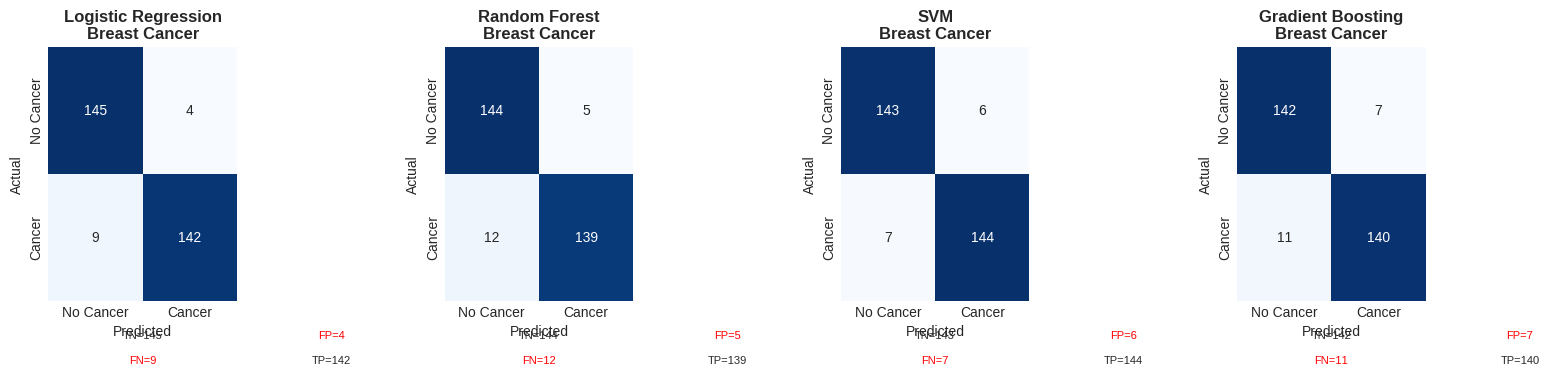


📊 Confusion Matrices - Lung Cancer


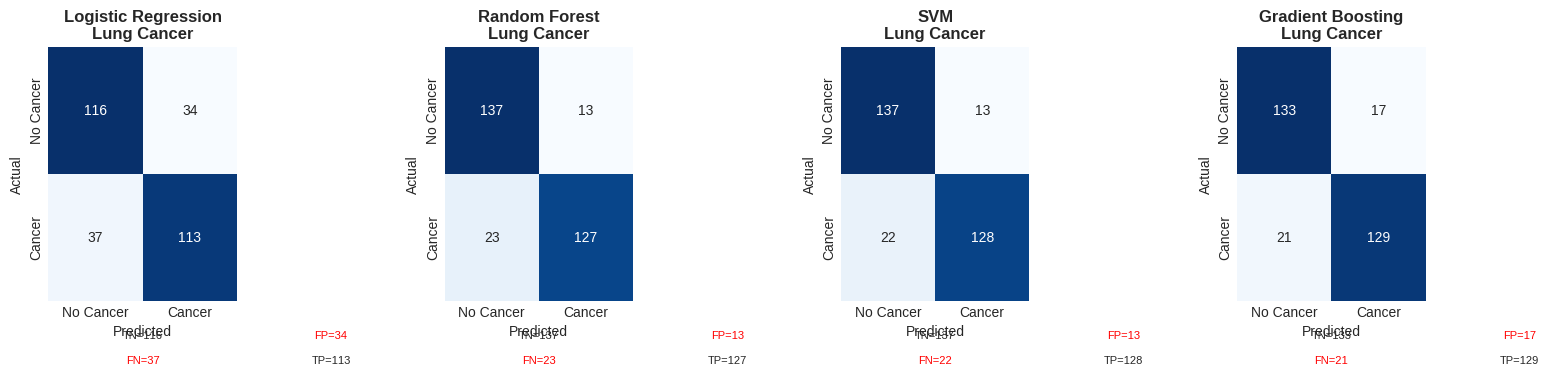


📊 Confusion Matrices - Colorectal Cancer


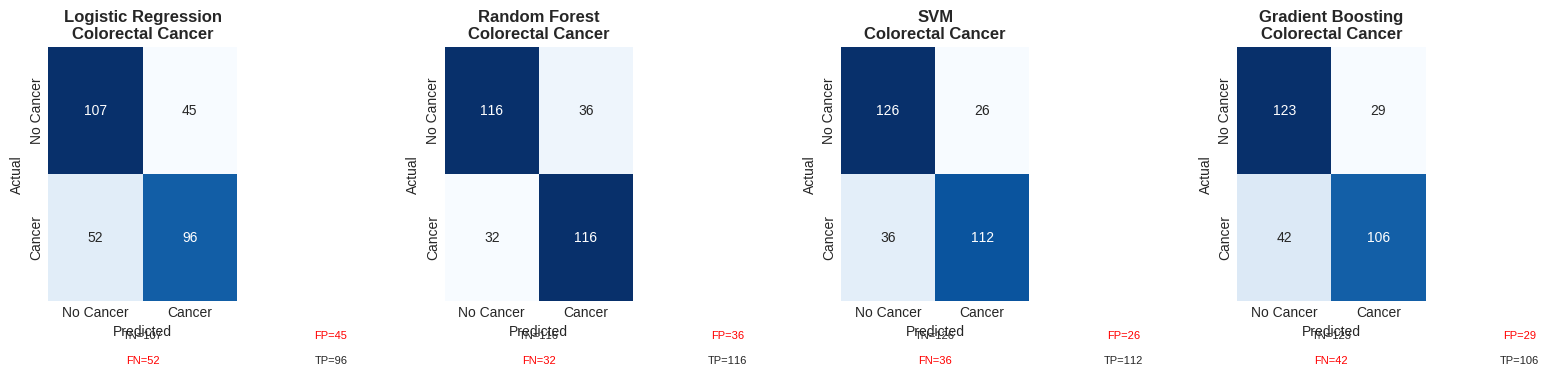

In [6]:
def plot_confusion_matrices(results_dict, dataset_name, figsize=(16, 4)):
    """
    Plot confusion matrices for all models side by side.
    """
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, result) in enumerate(results_dict.items()):
        cm = confusion_matrix(result['y_test'], result['y_pred'])
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['No Cancer', 'Cancer'],
                   yticklabels=['No Cancer', 'Cancer'],
                   ax=axes[idx], cbar=False)
        
        axes[idx].set_title(f'{model_name}\n{dataset_name}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Actual', fontsize=10)
        axes[idx].set_xlabel('Predicted', fontsize=10)
        
        # Add text annotations for clarity
        tn, fp, fn, tp = cm.ravel()
        axes[idx].text(0.5, -0.15, f'TN={tn}', ha='center', transform=axes[idx].transAxes, fontsize=8)
        axes[idx].text(1.5, -0.15, f'FP={fp}', ha='center', transform=axes[idx].transAxes, fontsize=8, color='red')
        axes[idx].text(0.5, -0.25, f'FN={fn}', ha='center', transform=axes[idx].transAxes, fontsize=8, color='red')
        axes[idx].text(1.5, -0.25, f'TP={tp}', ha='center', transform=axes[idx].transAxes, fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for all datasets
print("📊 Confusion Matrices - Breast Cancer")
plot_confusion_matrices(breast_results, 'Breast Cancer')

print("\n📊 Confusion Matrices - Lung Cancer")
plot_confusion_matrices(lung_results, 'Lung Cancer')

print("\n📊 Confusion Matrices - Colorectal Cancer")
plot_confusion_matrices(colorectal_results, 'Colorectal Cancer')

### 🔍 How to Interpret Confusion Matrices:

**Top-Left (TN - True Negatives)**:
- Correctly identified healthy patients
- ✅ Good! No unnecessary worry or procedures

**Top-Right (FP - False Positives)**:
- Healthy patients incorrectly flagged as cancer
- ⚠️ Causes anxiety, unnecessary biopsies, costs
- But better than missing cancer!

**Bottom-Left (FN - False Negatives)**:
- Cancer patients incorrectly cleared as healthy
- 🚨 VERY DANGEROUS! Delays treatment
- We want to MINIMIZE these!

**Bottom-Right (TP - True Positives)**:
- Correctly identified cancer patients
- ✅✅ Critical! Early detection saves lives

**Questions to ask:**
1. Which model has the fewest False Negatives?
2. Is there a trade-off between FP and FN?
3. Which mistakes are more acceptable in your context?

---

## 📈 Part 5: ROC Curves - The Complete Picture

### 🤔 What is an ROC Curve?

**ROC** = Receiver Operating Characteristic (fancy name, simple concept!)

**What it shows:**
- How well your model separates cancer from non-cancer patients
- The trade-off between catching cancer (Recall) and avoiding false alarms (Precision)

### 📊 Understanding the Plot:

**Y-axis (True Positive Rate / Recall)**:
- Goes from 0 to 1
- Higher = better at catching cancer
- "What % of cancer cases did we find?"

**X-axis (False Positive Rate)**:
- Goes from 0 to 1
- Lower = better (fewer false alarms)
- "What % of healthy people did we incorrectly flag?"

### 🎯 The Diagonal Line:
- Represents random guessing (AUC = 0.5)
- Like flipping a coin
- Any model should be ABOVE this line!

### 🏆 Interpreting AUC (Area Under Curve):
- **AUC = 0.5**: Random guessing (useless model)
- **AUC = 0.7-0.8**: Acceptable performance
- **AUC = 0.8-0.9**: Good performance
- **AUC = 0.9+**: Excellent performance
- **AUC = 1.0**: Perfect (rare in practice)

### 💡 Real-World Interpretation:
**AUC = 0.85 means:**
"If you randomly select one cancer patient and one healthy patient, there's an 85% chance the model will assign a higher cancer probability to the actual cancer patient."

📈 ROC Curves - Breast Cancer


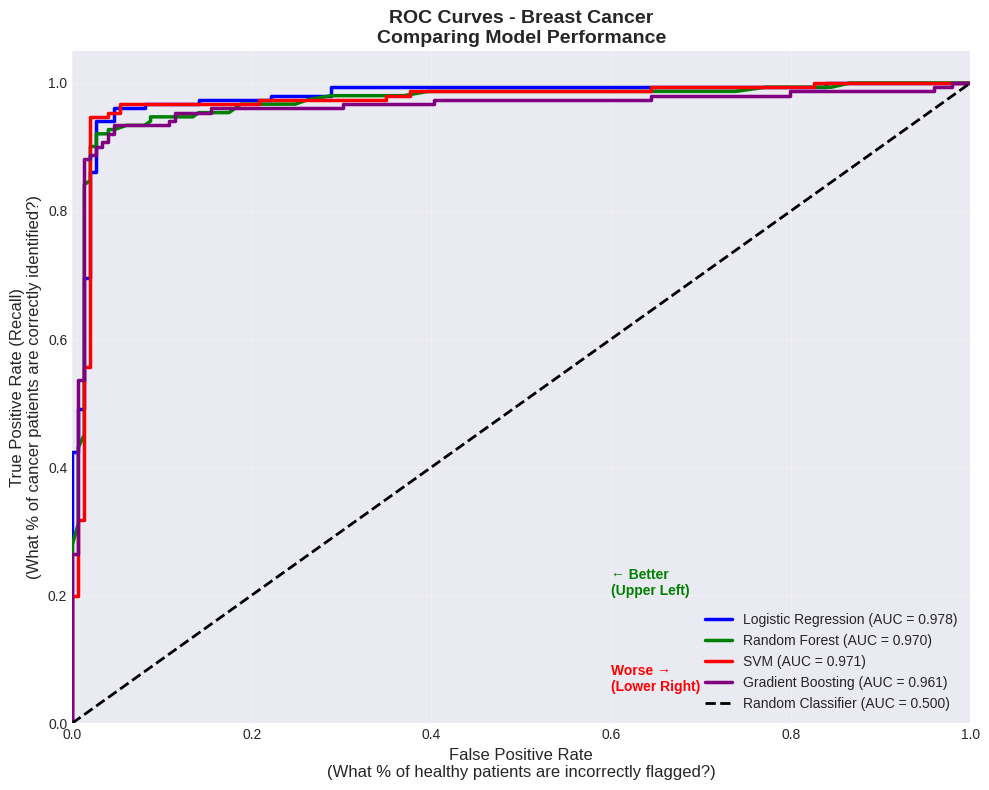


📈 ROC Curves - Lung Cancer


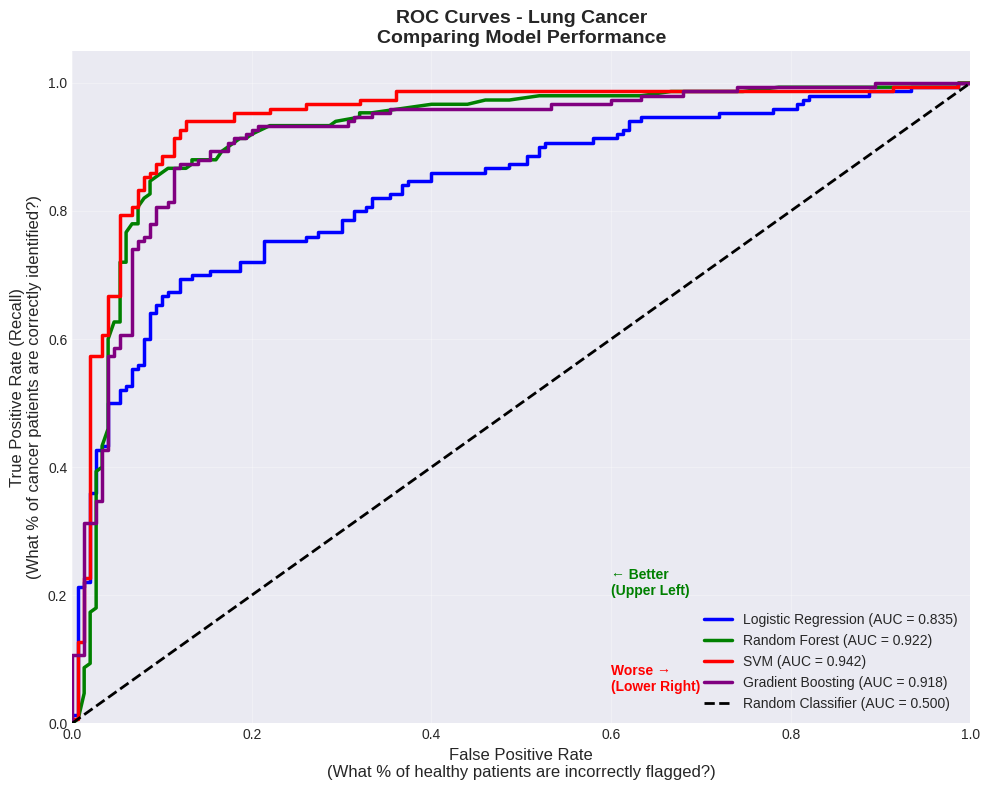


📈 ROC Curves - Colorectal Cancer


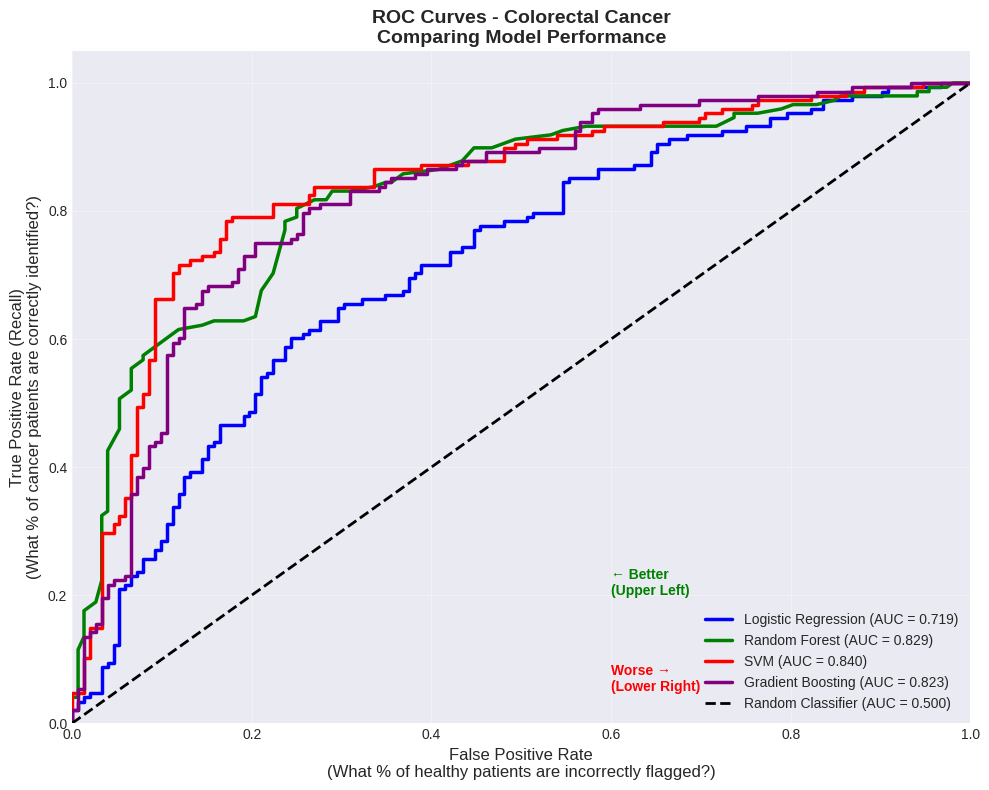

In [7]:
def plot_roc_curves(results_dict, dataset_name, figsize=(10, 8)):
    """
    Plot ROC curves for all models on the same plot.
    """
    plt.figure(figsize=figsize)
    
    colors = ['blue', 'green', 'red', 'purple']
    
    for idx, (model_name, result) in enumerate(results_dict.items()):
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(result['y_test'], result['y_pred_proba'])
        roc_auc = auc(fpr, tpr)
        
        # Plot
        plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2.5,
                label=f'{model_name} (AUC = {roc_auc:.3f})')
    
    # Plot diagonal (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate\n(What % of healthy patients are incorrectly flagged?)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)\n(What % of cancer patients are correctly identified?)', fontsize=12)
    plt.title(f'ROC Curves - {dataset_name}\nComparing Model Performance', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    # Add annotation
    plt.text(0.6, 0.2, '← Better\n(Upper Left)', fontsize=10, color='green', fontweight='bold')
    plt.text(0.6, 0.05, 'Worse →\n(Lower Right)', fontsize=10, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot ROC curves for all datasets
print("📈 ROC Curves - Breast Cancer")
plot_roc_curves(breast_results, 'Breast Cancer')

print("\n📈 ROC Curves - Lung Cancer")
plot_roc_curves(lung_results, 'Lung Cancer')

print("\n📈 ROC Curves - Colorectal Cancer")
plot_roc_curves(colorectal_results, 'Colorectal Cancer')

### 🎓 Key Takeaways from ROC Curves:

1. **Curve Position**:
   - The **higher and more to the left**, the better
   - Hugging the top-left corner = near-perfect model
   - Near the diagonal = no better than random guessing

2. **Comparing Models**:
   - The model with the **largest AUC** is generally best
   - BUT: Look at the full curve, not just AUC!
   - Different parts of the curve matter for different use cases

3. **Clinical Decisions**:
   - Left side of curve: High specificity (few false alarms)
   - Right side of curve: High sensitivity (catch most cancers)
   - You can choose where to operate based on your priorities

4. **Cross-Cancer Comparison**:
   - Notice how AUC varies across cancer types
   - Some cancers are inherently harder to detect
   - Model performance is data-dependent!

---

## 📊 Part 6: Visual Comparison Across All Metrics

### Why Visualize?
Numbers in tables are hard to digest. A good visualization lets you:
- Spot patterns instantly
- Compare multiple models at once
- Identify strengths and weaknesses
- Make informed decisions quickly

/tmp/ipykernel_1748/760085473.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


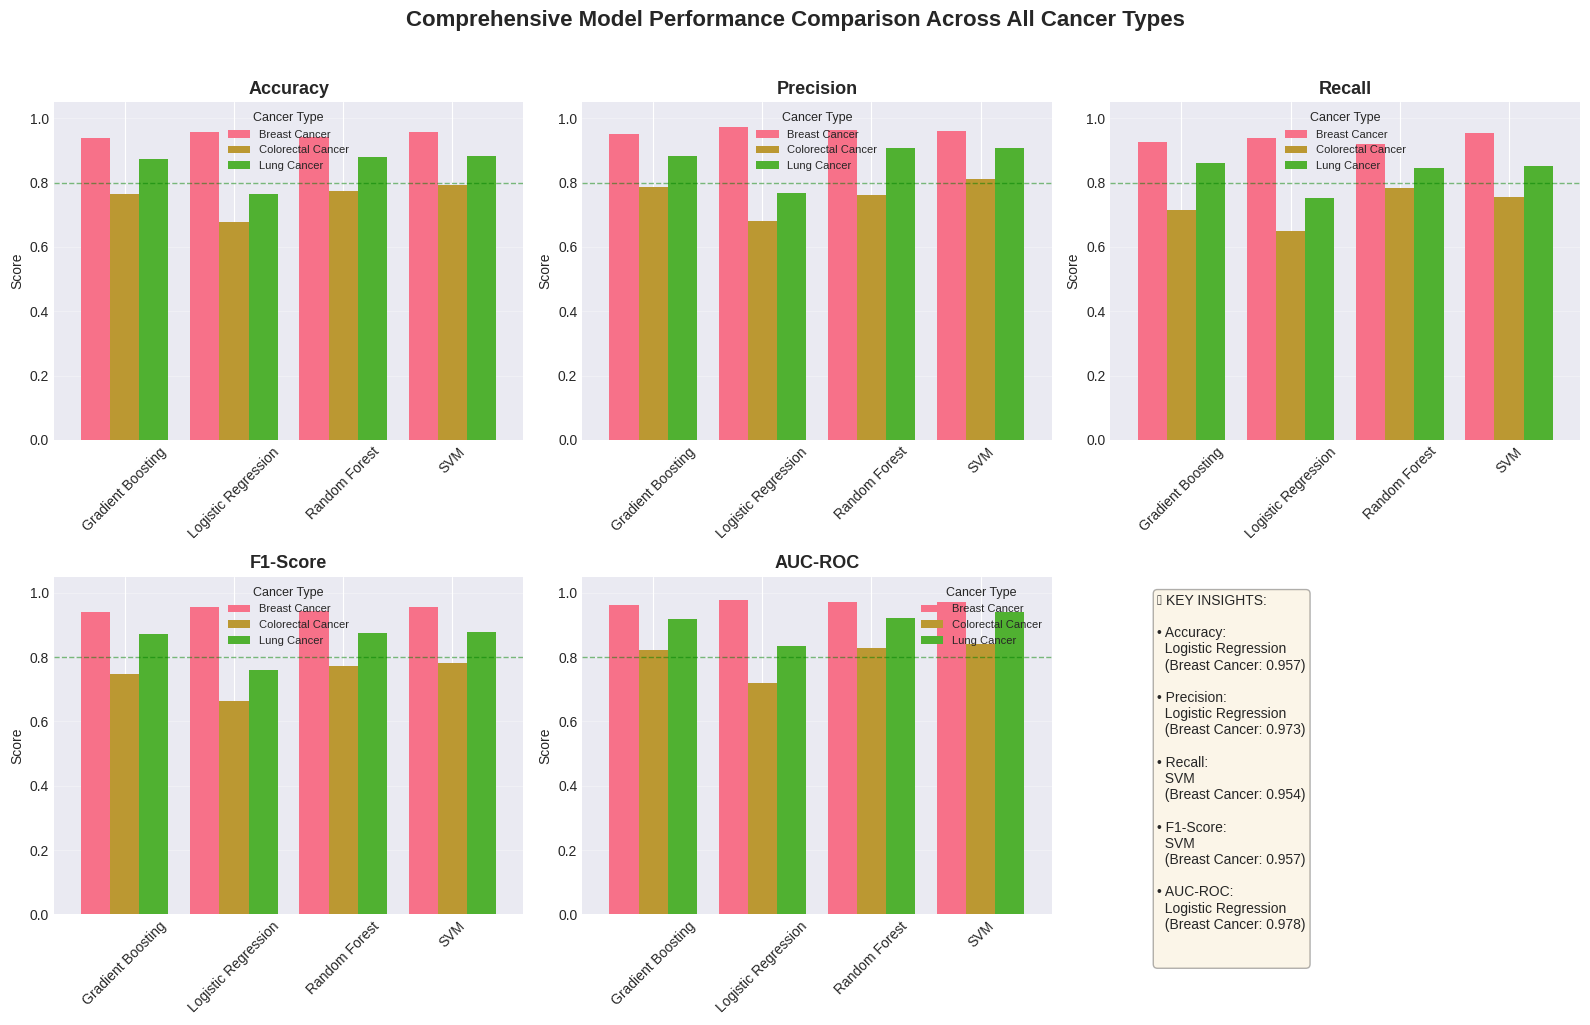

In [8]:
def plot_metrics_comparison(metrics_df, figsize=(16, 10)):
    """
    Create comprehensive visualization of all metrics.
    """
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Comprehensive Model Performance Comparison Across All Cancer Types', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    
    # Plot each metric
    for idx, metric in enumerate(metrics_to_plot):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        # Create grouped bar plot
        pivot_df = metrics_df.pivot(index='Model', columns='Dataset', values=metric)
        pivot_df.plot(kind='bar', ax=ax, width=0.8)
        
        ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Score', fontsize=10)
        ax.set_ylim([0, 1.05])
        ax.legend(title='Cancer Type', fontsize=8, title_fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Add horizontal line at 0.8 (generally considered "good")
        ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Good Threshold')
    
    # Use the last subplot for summary insights
    axes[1, 2].axis('off')
    
    # Calculate best model per metric
    summary_text = "📊 KEY INSIGHTS:\n\n"
    
    for metric in metrics_to_plot:
        best_idx = metrics_df[metric].idxmax()
        best_model = metrics_df.loc[best_idx, 'Model']
        best_dataset = metrics_df.loc[best_idx, 'Dataset']
        best_score = metrics_df.loc[best_idx, metric]
        summary_text += f"• {metric}:\n  {best_model}\n  ({best_dataset}: {best_score:.3f})\n\n"
    
    axes[1, 2].text(0.1, 0.95, summary_text, transform=axes[1, 2].transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create comprehensive visualization
plot_metrics_comparison(all_metrics_df)

### 🔍 What to Look For:

1. **Consistency Across Datasets**:
   - Does a model perform well on ALL cancer types?
   - Or is it only good for specific cancers?

2. **Metric Trade-offs**:
   - High Precision but Low Recall? → Conservative model (few false alarms, might miss cases)
   - High Recall but Low Precision? → Aggressive model (catches most cases, many false alarms)

3. **The "Best" Model**:
   - No single "best" model for all scenarios
   - Choose based on your priorities:
     - Cancer screening: Prioritize **Recall** (don't miss cancer!)
     - Confirmation test: Prioritize **Precision** (avoid false alarms)
     - General use: Prioritize **AUC-ROC** (balanced performance)

4. **Dataset Difficulty**:
   - Notice how ALL models perform worse on certain datasets
   - This tells us about the data, not just the models

---

## 🔬 Part 7: Statistical Significance Testing

### 🤔 Why Do We Need Statistical Tests?

**Scenario:** 
- Model A: 85% accuracy
- Model B: 87% accuracy

**Question:** Is Model B really better, or just lucky?

**Answer:** We need statistical tests to know!

### 📊 The Problem:
- Small differences might be due to **random chance**
- Testing on a single random split of data isn't enough
- We need to ensure differences are **statistically significant**

### ✅ Solution: Cross-Validation + Statistical Tests

**Cross-Validation:**
- Split data into K "folds" (typically 5 or 10)
- Train and test K times, each time using different fold as test set
- Get K performance scores → measure of stability

**Statistical Tests:**
1. **Paired t-test**: Compare mean performance of two models
2. **Wilcoxon signed-rank test**: Non-parametric alternative (doesn't assume normal distribution)
3. **ANOVA**: Compare more than two models simultaneously

### 🎯 P-value Interpretation:
- **p < 0.05**: "Statistically significant" difference (95% confident it's not random)
- **p < 0.01**: "Highly significant" (99% confident)
- **p ≥ 0.05**: No significant difference (could be random chance)

**Important:** P-value tells you if the difference is *real*, not if it's *important*!

In [9]:
def perform_cross_validation(X, y, models_dict, cv=5, random_state=42):
    """
    Perform k-fold cross-validation for all models.
    
    Returns:
    - DataFrame with cross-validation scores for each model
    """
    cv_results = {}
    
    # Create stratified K-fold (maintains class balance in each fold)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    for model_name, model_obj in models_dict.items():
        # Perform cross-validation
        scores = cross_val_score(model_obj, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
        cv_results[model_name] = scores
    
    # Create DataFrame
    cv_df = pd.DataFrame(cv_results)
    
    return cv_df

# Perform cross-validation for all datasets
print("🔄 Performing 5-Fold Cross-Validation...\n")

models_for_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Cross-validation for each dataset
print("📊 Breast Cancer Dataset:")
cv_breast = perform_cross_validation(X_breast, y_breast, models_for_cv)
print(cv_breast)
print(f"\nMean AUC-ROC scores:\n{cv_breast.mean().sort_values(ascending=False)}")
print(f"\nStd deviation:\n{cv_breast.std().sort_values()}")

print("\n" + "="*80 + "\n")

print("📊 Lung Cancer Dataset:")
cv_lung = perform_cross_validation(X_lung, y_lung, models_for_cv)
print(cv_lung)
print(f"\nMean AUC-ROC scores:\n{cv_lung.mean().sort_values(ascending=False)}")
print(f"\nStd deviation:\n{cv_lung.std().sort_values()}")

print("\n" + "="*80 + "\n")

print("📊 Colorectal Cancer Dataset:")
cv_colorectal = perform_cross_validation(X_colorectal, y_colorectal, models_for_cv)
print(cv_colorectal)
print(f"\nMean AUC-ROC scores:\n{cv_colorectal.mean().sort_values(ascending=False)}")
print(f"\nStd deviation:\n{cv_colorectal.std().sort_values()}")

🔄 Performing 5-Fold Cross-Validation...

📊 Breast Cancer Dataset:
   Logistic Regression  Random Forest       SVM  Gradient Boosting
0             0.973297       0.960896  0.966197           0.960496
1             0.992299       0.987749  0.991799           0.986699
2             0.972597       0.967647  0.970497           0.963996
3             0.968197       0.968597  0.974097           0.965597
4             0.988099       0.997600  0.995400           0.992699

Mean AUC-ROC scores:
SVM                    0.979598
Logistic Regression    0.978898
Random Forest          0.976498
Gradient Boosting      0.973897
dtype: float64

Std deviation:
Logistic Regression    0.010605
SVM                    0.013146
Gradient Boosting      0.014696
Random Forest          0.015460
dtype: float64


📊 Lung Cancer Dataset:
   Logistic Regression  Random Forest       SVM  Gradient Boosting
0             0.793079       0.915142  0.923292           0.889789
1             0.822700       0.912250  0.917700  

### 📊 Understanding Cross-Validation Results:

**Each row** = one fold (one train/test split)
**Each column** = one model's performance

**What to look for:**

1. **Mean Score**:
   - Average performance across all folds
   - More reliable than single test score

2. **Standard Deviation (Std)**:
   - How much performance varies between folds
   - **Lower std** = more stable/reliable model
   - **Higher std** = performance depends heavily on data split

3. **Score Range**:
   - Look at min and max scores
   - Large range = unstable model

**Example:**
- Model A: Mean = 0.85, Std = 0.02 (stable!)
- Model B: Mean = 0.87, Std = 0.10 (unstable!)
- Which would you choose? (Hint: Consider the context!)

📊 Cross-Validation Results Visualization



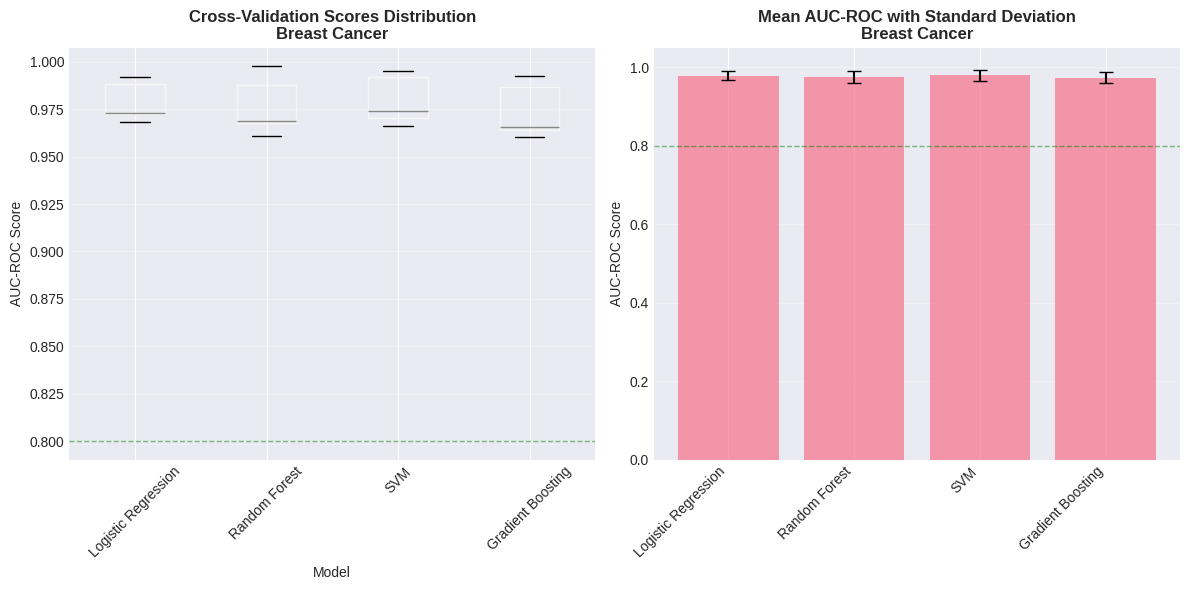

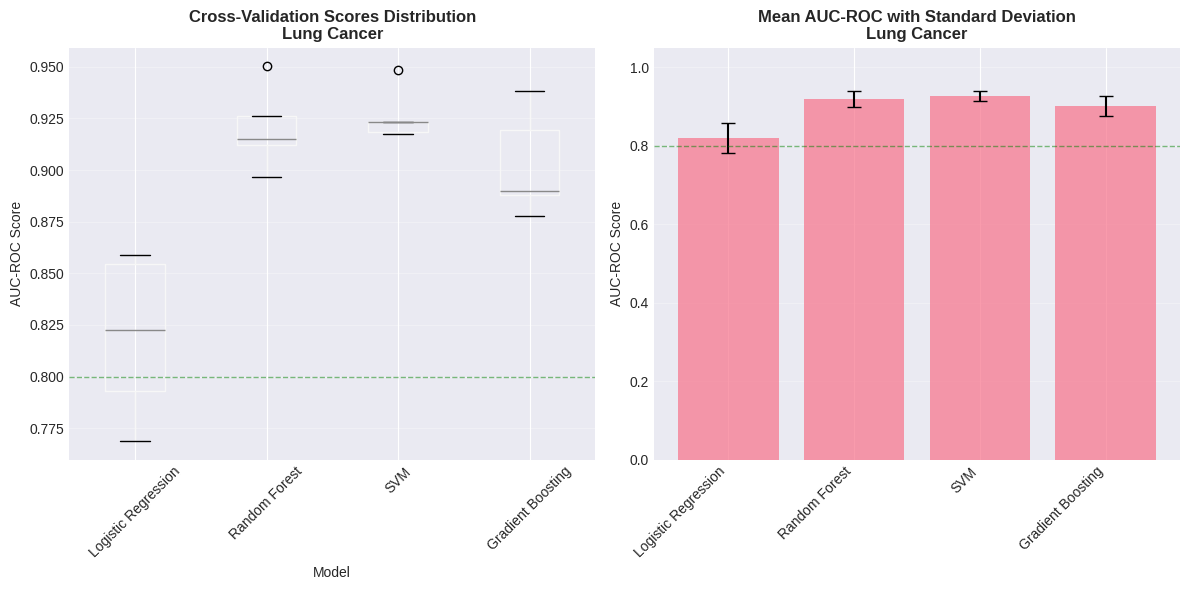

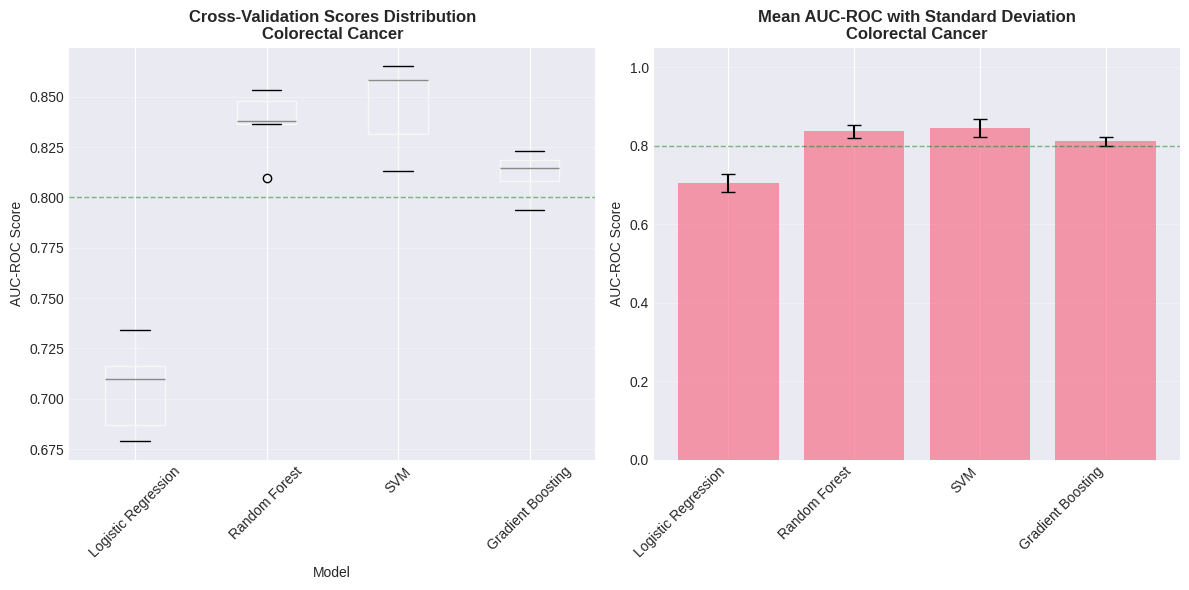

In [10]:
def plot_cv_results(cv_df, dataset_name, figsize=(12, 6)):
    """
    Visualize cross-validation results with boxplots.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Boxplot
    cv_df.boxplot(ax=ax1)
    ax1.set_title(f'Cross-Validation Scores Distribution\n{dataset_name}', fontweight='bold')
    ax1.set_ylabel('AUC-ROC Score')
    ax1.set_xlabel('Model')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    # Bar plot with error bars
    means = cv_df.mean()
    stds = cv_df.std()
    
    x_pos = np.arange(len(means))
    ax2.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(means.index, rotation=45, ha='right')
    ax2.set_title(f'Mean AUC-ROC with Standard Deviation\n{dataset_name}', fontweight='bold')
    ax2.set_ylabel('AUC-ROC Score')
    ax2.set_ylim([0, 1.05])
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Plot CV results
print("📊 Cross-Validation Results Visualization\n")
plot_cv_results(cv_breast, 'Breast Cancer')
plot_cv_results(cv_lung, 'Lung Cancer')
plot_cv_results(cv_colorectal, 'Colorectal Cancer')

---

## 📈 Part 8: Statistical Hypothesis Testing (Optional)

### 🎯 The Goal:
Determine if the performance difference between models is **statistically significant** or just **random chance**.

### 📝 Hypothesis Testing Framework:

**Null Hypothesis (H₀):**
- "There is NO difference between models"
- Any observed difference is due to random chance

**Alternative Hypothesis (H₁):**
- "There IS a significant difference between models"
- The difference is real and reproducible

### 🧪 Tests We'll Use:

1. **Paired t-test**:
   - Compares two models
   - Assumes normal distribution
   - Uses: "Is Model A significantly better than Model B?"

2. **Wilcoxon Signed-Rank Test**:
   - Non-parametric alternative to t-test
   - Doesn't assume normal distribution
   - More robust for small samples

3. **Friedman Test**:
   - Compares 3+ models simultaneously
   - Non-parametric version of repeated measures ANOVA
   - Uses: "Is there ANY significant difference among all models?"

In [11]:
def perform_statistical_tests(cv_df, dataset_name):
    """
    Perform various statistical tests to compare models.
    """
    print("="*80)
    print(f"📊 STATISTICAL TESTS - {dataset_name}")
    print("="*80)
    
    model_names = cv_df.columns.tolist()
    
    # 1. Friedman Test (comparing all models)
    print("\n1️⃣ FRIEDMAN TEST (Comparing All Models Simultaneously)")
    print("-" * 80)
    print("Null Hypothesis: No difference among any models")
    print("Alternative: At least one model is significantly different\n")
    
    # Prepare data for Friedman test
    data_for_friedman = [cv_df[col].values for col in model_names]
    friedman_stat, friedman_p = stats.friedmanchisquare(*data_for_friedman)
    
    print(f"Friedman Statistic: {friedman_stat:.4f}")
    print(f"P-value: {friedman_p:.6f}")
    
    if friedman_p < 0.05:
        print("✅ Result: SIGNIFICANT difference detected (p < 0.05)")
        print("   → At least one model performs significantly differently")
        print("   → Proceed with pairwise comparisons")
    else:
        print("❌ Result: NO significant difference (p ≥ 0.05)")
        print("   → Models perform similarly")
        print("   → Differences might be due to random chance")
    
    # 2. Pairwise comparisons
    print("\n\n2️⃣ PAIRWISE COMPARISONS (t-test and Wilcoxon)")
    print("-" * 80)
    print("Comparing each pair of models...\n")
    
    pairwise_results = []
    
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]
            
            scores1 = cv_df[model1].values
            scores2 = cv_df[model2].values
            
            # Paired t-test
            t_stat, t_p = stats.ttest_rel(scores1, scores2)
            
            # Wilcoxon signed-rank test
            w_stat, w_p = stats.wilcoxon(scores1, scores2)
            
            # Mean difference
            mean_diff = scores1.mean() - scores2.mean()
            
            pairwise_results.append({
                'Comparison': f'{model1} vs {model2}',
                'Mean Diff': mean_diff,
                't-test p-value': t_p,
                'Wilcoxon p-value': w_p,
                'Significant (p<0.05)': 'Yes' if t_p < 0.05 else 'No'
            })
    
    pairwise_df = pd.DataFrame(pairwise_results)
    print(pairwise_df.to_string(index=False))
    
    # 3. Summary and interpretation
    print("\n\n3️⃣ INTERPRETATION GUIDE")
    print("-" * 80)
    print("📌 How to read p-values:")
    print("   • p < 0.001: Very strong evidence of difference (***) ")
    print("   • p < 0.01:  Strong evidence of difference (**) ")
    print("   • p < 0.05:  Significant evidence of difference (*) ")
    print("   • p ≥ 0.05:  No significant difference (could be random)\n")
    
    print("📌 Mean Difference:")
    print("   • Positive: First model performs better")
    print("   • Negative: Second model performs better")
    print("   • Close to 0: Very similar performance\n")
    
    # Find best model
    best_model = cv_df.mean().idxmax()
    best_score = cv_df.mean().max()
    best_std = cv_df[best_model].std()
    
    print("\n" + "="*80)
    print(f"🏆 BEST MODEL: {best_model}")
    print(f"   Mean AUC-ROC: {best_score:.4f} (±{best_std:.4f})")
    
    # Check if best model is significantly better than others
    significant_wins = 0
    for _, row in pairwise_df.iterrows():
        if best_model in row['Comparison'] and row['Significant (p<0.05)'] == 'Yes':
            if (best_model == row['Comparison'].split(' vs ')[0] and row['Mean Diff'] > 0) or \
               (best_model == row['Comparison'].split(' vs ')[1] and row['Mean Diff'] < 0):
                significant_wins += 1
    
    print(f"   Significantly better than {significant_wins} other model(s)")
    print("="*80 + "\n")
    
    return pairwise_df

# Perform statistical tests for all datasets
breast_stats = perform_statistical_tests(cv_breast, 'Breast Cancer')
lung_stats = perform_statistical_tests(cv_lung, 'Lung Cancer')
colorectal_stats = perform_statistical_tests(cv_colorectal, 'Colorectal Cancer')

📊 STATISTICAL TESTS - Breast Cancer

1️⃣ FRIEDMAN TEST (Comparing All Models Simultaneously)
--------------------------------------------------------------------------------
Null Hypothesis: No difference among any models
Alternative: At least one model is significantly different

Friedman Statistic: 7.3200
P-value: 0.062368
❌ Result: NO significant difference (p ≥ 0.05)
   → Models perform similarly
   → Differences might be due to random chance


2️⃣ PAIRWISE COMPARISONS (t-test and Wilcoxon)
--------------------------------------------------------------------------------
Comparing each pair of models...

                              Comparison  Mean Diff  t-test p-value  Wilcoxon p-value Significant (p<0.05)
    Logistic Regression vs Random Forest   0.002400        0.542485            0.6250                   No
              Logistic Regression vs SVM  -0.000700        0.804897            1.0000                   No
Logistic Regression vs Gradient Boosting   0.005001        0.163

### 💡 Interpreting Statistical Test Results:

#### When p < 0.05:
✅ **"Statistically Significant"**
- The performance difference is likely real, not due to chance
- We can be 95% confident in this conclusion
- Safe to say one model is genuinely better

#### When p ≥ 0.05:
❌ **"Not Statistically Significant"**
- Cannot confidently say models are different
- Observed difference might be random
- Consider them equivalent in performance
- Choose based on other factors (speed, interpretability, etc.)

#### Important Caveats:
1. **Statistical ≠ Practical**
   - A difference can be statistically significant but too small to matter in practice
   - Example: 0.001 improvement in accuracy (significant, but who cares?)

2. **Consider Effect Size**
   - Look at the actual mean difference, not just p-value
   - Large datasets can make tiny differences "significant"

3. **Multiple Comparisons Problem**
   - More tests = higher chance of false positives
   - Consider Bonferroni correction for many comparisons

4. **Context Matters**
   - In cancer detection, even small improvements matter!
   - 1% better recall = more lives saved

---

## 🌍 Part 9: Cross-Cancer Performance Analysis

### 🤔 Why Compare Across Cancer Types?

**Real-world implications:**
- Hospitals want models that work for **multiple cancer types**
- Developing separate models is expensive and time-consuming
- Understanding which models **generalize well** is crucial

### 📊 What We're Looking For:

1. **Consistent Performers**:
   - Models that work well across all cancer types
   - Lower risk, more reliable

2. **Specialized Champions**:
   - Models that excel at specific cancer types
   - Might be worth using different models for different cancers

3. **Dataset Difficulty**:
   - Some cancers are inherently harder to detect
   - Understanding this helps set realistic expectations

4. **Model-Cancer Interactions**:
   - Why does Model A work better for breast cancer?
   - Why does Model B struggle with colorectal cancer?
   - These insights guide model selection and improvement

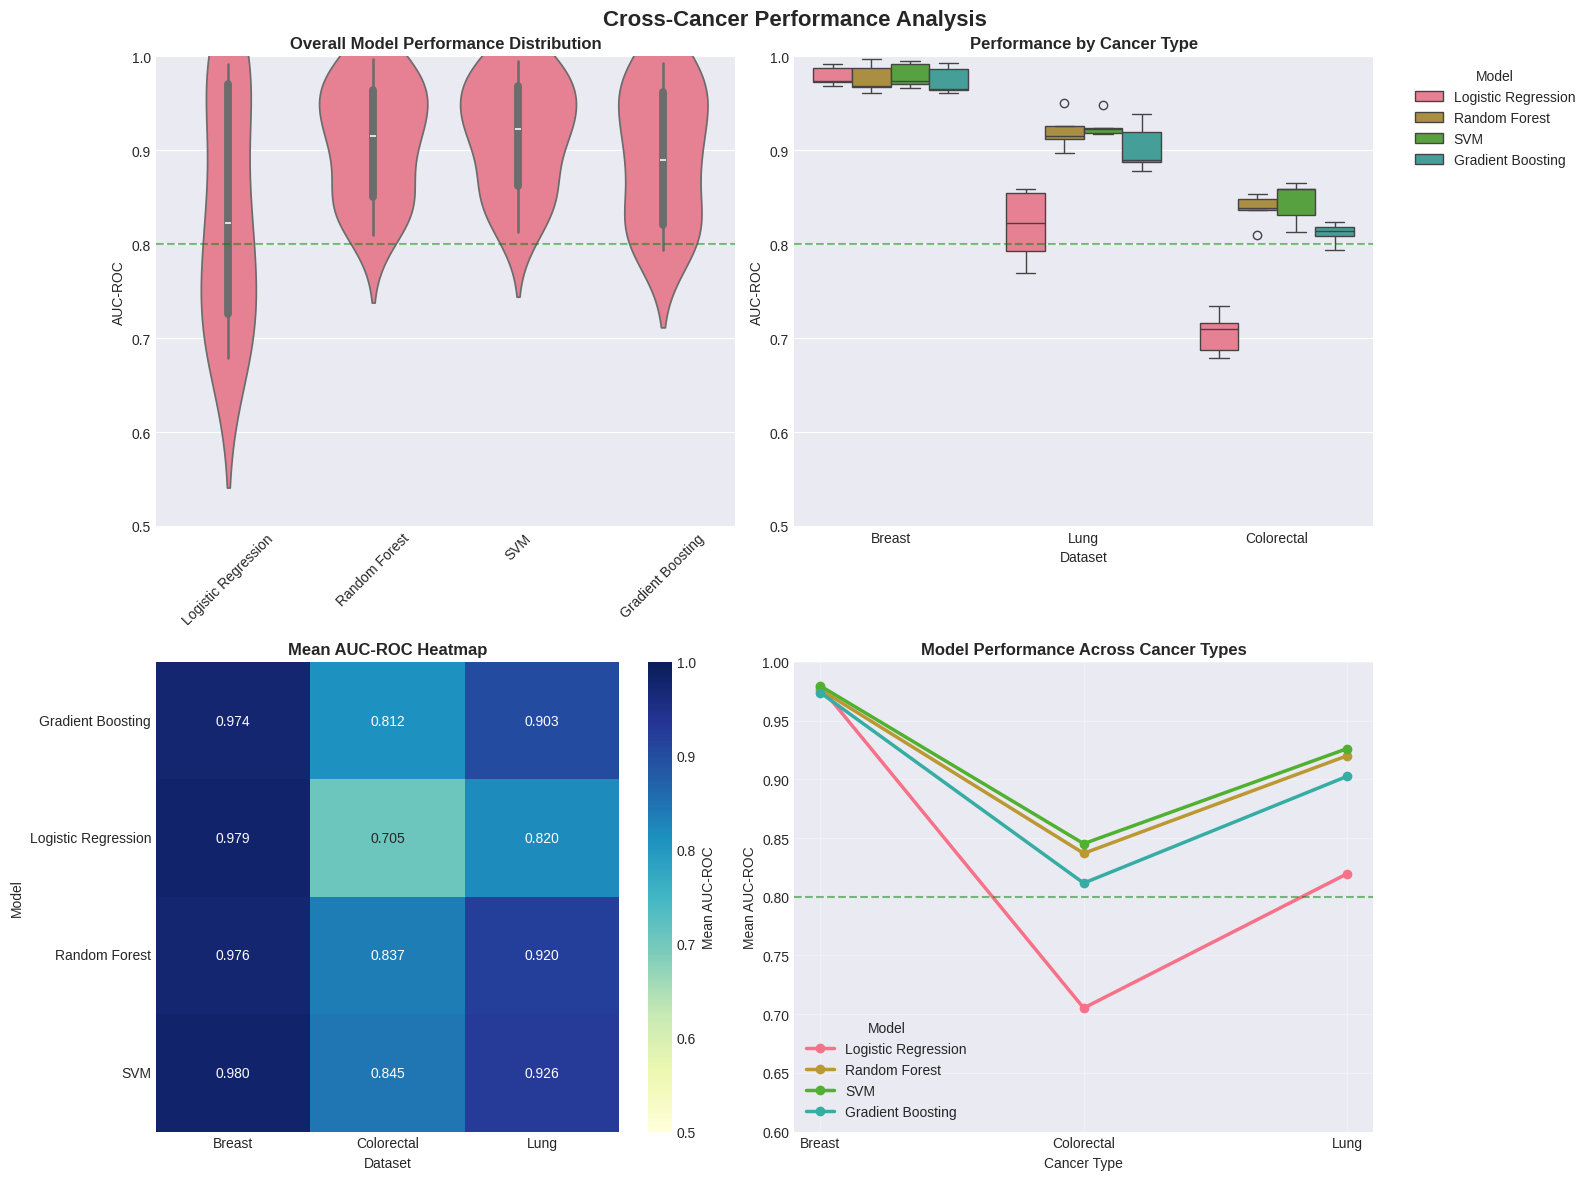


📊 CROSS-CANCER STATISTICAL SUMMARY
                                    mean       std       min       max
Model               Dataset                                           
Gradient Boosting   Breast      0.973897  0.014696  0.960496  0.992699
                    Colorectal  0.811641  0.011393  0.793779  0.823182
                    Lung        0.902558  0.025325  0.877600  0.938400
Logistic Regression Breast      0.978898  0.010605  0.968197  0.992299
                    Colorectal  0.705211  0.022313  0.679068  0.734073
                    Lung        0.819556  0.038866  0.768800  0.858900
Random Forest       Breast      0.976498  0.015460  0.960896  0.997600
                    Colorectal  0.836994  0.016930  0.809381  0.853135
                    Lung        0.920078  0.019848  0.896700  0.950200
SVM                 Breast      0.979598  0.013146  0.966197  0.995400
                    Colorectal  0.845225  0.022122  0.812981  0.864986
                    Lung        0.926158 

In [12]:
# Combine all cross-validation results
cv_breast['Dataset'] = 'Breast'
cv_lung['Dataset'] = 'Lung'
cv_colorectal['Dataset'] = 'Colorectal'

# Reshape for easier analysis
cv_breast_long = cv_breast.melt(id_vars='Dataset', var_name='Model', value_name='AUC-ROC')
cv_lung_long = cv_lung.melt(id_vars='Dataset', var_name='Model', value_name='AUC-ROC')
cv_colorectal_long = cv_colorectal.melt(id_vars='Dataset', var_name='Model', value_name='AUC-ROC')

all_cv_results = pd.concat([cv_breast_long, cv_lung_long, cv_colorectal_long], ignore_index=True)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cross-Cancer Performance Analysis', fontsize=16, fontweight='bold')

# 1. Violin plot by model
ax1 = axes[0, 0]
sns.violinplot(data=all_cv_results, x='Model', y='AUC-ROC', ax=ax1)
ax1.set_title('Overall Model Performance Distribution', fontweight='bold')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
ax1.set_ylim([0.5, 1.0])

# 2. Grouped box plot
ax2 = axes[0, 1]
sns.boxplot(data=all_cv_results, x='Dataset', y='AUC-ROC', hue='Model', ax=ax2)
ax2.set_title('Performance by Cancer Type', fontweight='bold')
ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
ax2.set_ylim([0.5, 1.0])

# 3. Heatmap of mean performance
ax3 = axes[1, 0]
pivot_mean = all_cv_results.groupby(['Model', 'Dataset'])['AUC-ROC'].mean().unstack()
sns.heatmap(pivot_mean, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax3, 
            cbar_kws={'label': 'Mean AUC-ROC'}, vmin=0.5, vmax=1.0)
ax3.set_title('Mean AUC-ROC Heatmap', fontweight='bold')
ax3.set_ylabel('Model')

# 4. Line plot showing trends
ax4 = axes[1, 1]
for model in all_cv_results['Model'].unique():
    model_data = all_cv_results[all_cv_results['Model'] == model]
    mean_scores = model_data.groupby('Dataset')['AUC-ROC'].mean()
    ax4.plot(mean_scores.index, mean_scores.values, marker='o', label=model, linewidth=2.5)

ax4.set_title('Model Performance Across Cancer Types', fontweight='bold')
ax4.set_xlabel('Cancer Type')
ax4.set_ylabel('Mean AUC-ROC')
ax4.legend(title='Model')
ax4.grid(alpha=0.3)
ax4.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax4.set_ylim([0.6, 1.0])

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*80)
print("📊 CROSS-CANCER STATISTICAL SUMMARY")
print("="*80)

summary = all_cv_results.groupby(['Model', 'Dataset'])['AUC-ROC'].agg(['mean', 'std', 'min', 'max'])
print(summary)

print("\n" + "="*80)
print("🏆 RANKINGS")
print("="*80)

# Overall ranking
overall_ranking = all_cv_results.groupby('Model')['AUC-ROC'].mean().sort_values(ascending=False)
print("\n📈 Overall Performance Ranking (Mean AUC-ROC across all datasets):")
for rank, (model, score) in enumerate(overall_ranking.items(), 1):
    print(f"  {rank}. {model}: {score:.4f}")

# By dataset
for dataset in ['Breast', 'Lung', 'Colorectal']:
    dataset_ranking = all_cv_results[all_cv_results['Dataset'] == dataset].groupby('Model')['AUC-ROC'].mean().sort_values(ascending=False)
    print(f"\n🧬 {dataset} Cancer Ranking:")
    for rank, (model, score) in enumerate(dataset_ranking.items(), 1):
        print(f"  {rank}. {model}: {score:.4f}")

### 🔍 Key Insights from Cross-Cancer Analysis:

#### 1. **Generalization vs. Specialization**:
- **Generalist**: Model performs consistently across all cancer types
  - Pros: One model for all, simpler deployment
  - Cons: Might not be optimal for any specific type
- **Specialist**: Model excels at certain types but not others
  - Pros: Best performance for specific cases
  - Cons: Need multiple models, more complex system

#### 2. **Dataset Difficulty**:
- Notice if ALL models struggle with certain cancer types
- This suggests:
  - More complex data patterns
  - Need for more data
  - Need for better features
  - Realistic performance expectations

#### 3. **Stability Assessment**:
- Look at standard deviation across folds
- Lower std = more reliable model
- High std = performance varies greatly with data

#### 4. **Clinical Implications**:
- **Multi-cancer screening**: Use the most consistent model
- **Single-cancer screening**: Use the best specialist for that type
- **Resource constraints**: Balance performance vs. complexity

---

## 🎓 Part 10: Final Summary & Best Practices

### 📚 What We've Learned:

#### 1. **Multiple Metrics Are Essential** 🎯
- **Never rely on accuracy alone** - especially with imbalanced data
- Each metric tells a different story:
  - Accuracy: Overall correctness
  - Precision: How reliable are positive predictions?
  - Recall: How many positives did we catch?
  - AUC-ROC: Overall discriminative ability
- **Choose metrics based on your goal**:
  - Cancer screening → Prioritize Recall
  - Spam detection → Balance Precision and Recall
  - General classification → AUC-ROC is a good starting point

#### 2. **ROC Curves Provide Complete Picture** 📈
- Show performance across ALL possible thresholds
- Allow comparison of multiple models visually
- AUC provides single number summary
- **Higher and more to the left = better**

#### 3. **Statistical Testing Is Crucial** 🔬
- Small differences might be random chance
- Use cross-validation for reliable estimates
- Perform statistical tests to validate differences
- **p < 0.05**: Difference is likely real
- **p ≥ 0.05**: Models might be equivalent

#### 4. **Context Matters** 🌍
- Same model may perform differently on different datasets
- Understand your data characteristics
- Balance multiple objectives (performance, speed, interpretability)
- Consider real-world deployment constraints

---

### ✅ Best Practices Checklist:

**Before Training:**
- [ ] Understand your data and class distribution
- [ ] Define what success means for your problem
- [ ] Choose appropriate metrics based on consequences of errors

**During Evaluation:**
- [ ] Use multiple metrics, never just accuracy
- [ ] Perform cross-validation (at least 5-fold)
- [ ] Plot confusion matrices to understand errors
- [ ] Generate ROC curves for visual comparison
- [ ] Calculate mean and standard deviation of performance

**Statistical Validation:**
- [ ] Test for significant differences between models
- [ ] Use appropriate statistical tests (t-test, Wilcoxon, Friedman)
- [ ] Check both statistical AND practical significance
- [ ] Consider multiple comparison corrections if needed

**Model Selection:**
- [ ] Don't just pick highest score - consider stability (std)
- [ ] Verify model generalizes to different datasets
- [ ] Balance performance with interpretability and complexity
- [ ] Consider deployment constraints (speed, memory, etc.)

**Documentation:**
- [ ] Report all metrics, not just the best one
- [ ] Include confidence intervals or standard deviations
- [ ] Document cross-validation strategy
- [ ] Report statistical test results
- [ ] Acknowledge limitations

---

### 🚀 Next Steps:

1. **Apply to Your Data**:
   - Replace synthetic data with your real dataset
   - Adjust models and parameters as needed
   - Interpret results in your specific context

2. **Experiment**:
   - Try different models
   - Tune hyperparameters
   - Engineer new features

3. **Deep Dive**:
   - Learn about model interpretability (SHAP, LIME)
   - Study advanced cross-validation techniques
   - Explore ensemble methods

4. **Keep Learning**:
   - Read papers on model evaluation in your domain
   - Study real-world case studies
   - Join ML communities and discussions

---

### 💡 Common Pitfalls to Avoid:

1. **❌ Data Leakage**: Never use test data during training
2. **❌ Overfitting**: High training score, low test score
3. **❌ Cherry-picking**: Reporting only favorable metrics
4. **❌ Ignoring class imbalance**: Accuracy can be misleading
5. **❌ Single test split**: Always use cross-validation
6. **❌ Ignoring confidence intervals**: Report uncertainty!
7. **❌ Blindly trusting p-values**: Consider effect size too
8. **❌ Over-complicated models**: Simple is often better

---

### 🎯 Remember:

> **"All models are wrong, but some are useful."** - George Box

The goal isn't perfection - it's finding the **most useful** model for **your specific problem** with **rigorous evaluation** to back up your claims.

---

## 🎉 Congratulations!

You now understand:
- ✅ How to evaluate ML models properly
- ✅ Why multiple metrics matter
- ✅ How to interpret ROC curves
- ✅ How to validate model differences statistically
- ✅ How to compare models across different datasets

**You're ready to rigorously evaluate your own models!** 🚀

---

## 📖 Additional Resources:

### Books:
- "Hands-On Machine Learning" by Aurélien Géron
- "Pattern Recognition and Machine Learning" by Christopher Bishop
- "The Elements of Statistical Learning" by Hastie, Tibshirani, and Friedman

### Online Resources:
- Scikit-learn Documentation: https://scikit-learn.org/
- Towards Data Science: https://towardsdatascience.com/
- Kaggle Learn: https://www.kaggle.com/learn

### Papers:
- "A Survey on Model Evaluation and Comparison" (various authors)
- "Statistical Comparisons of Classifiers over Multiple Data Sets" by Demšar (2006)
- "ROC Curves for Continuous Data" by Fawcett (2006)

---

## 📝 Exercise Ideas:

1. **Beginner**: Run this notebook and understand all outputs
2. **Intermediate**: Modify parameters and observe changes
3. **Advanced**: Apply to your own dataset and interpret results
4. **Expert**: Implement additional statistical tests (McNemar's, Cochran's Q)

---

### 🙋 Questions?

- Read through the markdown explanations again
- Experiment with the code
- Search for specific concepts online
- Join ML communities (Reddit r/MachineLearning, Stack Overflow)

**Happy Learning! 🎓📊🚀**